# Linearly Constrained Sinkhorn with OTT-JAX

Matthieu Kaeppelin. Optimal Transport course

**Reference.** Tang, Toh & Tian, [*A Sinkhorn-type Algorithm for Constrained Optimal Transport*](https://arxiv.org/abs/2403.05054), 2024.

---

Sinkhorn handles entropic OT very well as long as the only constraints on the coupling $P$ are its marginals. Many problems however come with additional linear structure on $P$: a secondary cost we want to keep below a budget, a fairness or diversity quantity to enforce, an expectation $\langle D, P\rangle$ to pin down. Tang, Toh & Tian (2024) showed how Sinkhorn can be adapted to those settings, with the rather pleasant property that the constraints fold neatly into the cost matrix. The algorithm therefore plugs almost transparently on top of OTT-JAX.

I derive the algorithm below, implement it as a few short JAX functions, validate every primitive, and use it on three problems: the random-assignment setup of §5 of the paper, a Pareto frontier between two transport costs, and a diversity-constrained matching problem that does not appear in the paper.

In [1]:
# !pip install -q ott-jax matplotlib
from functools import partial

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

jax.config.update("jax_enable_x64", True)

from ott.geometry import geometry, pointcloud
from ott.solvers.linear import solve as sinkhorn_solve

import ott
print(f"OTT-JAX version: {ott.__version__}")
print(f"JAX devices:     {jax.devices()}")

OTT-JAX version: 0.6.0
JAX devices:     [CpuDevice(id=0)]


## 1. Standard entropic OT, in one OTT-JAX call

Given source weights $r \in \Delta^m$, target weights $c \in \Delta^n$, and a cost $C \in \mathbb{R}^{m\times n}$, **entropic OT** is

$$P^\star \;=\; \arg\min_{P \in \Pi(r,c)} \langle C, P\rangle - \tfrac{1}{\eta} H(P), \qquad \Pi(r,c) = \{P\geq 0 : P\mathbf 1 = r,\ P^\top \mathbf 1 = c\}.$$

OTT-JAX solves this in three lines. Below is a tiny demo with two 2D point clouds, just to anchor the API.

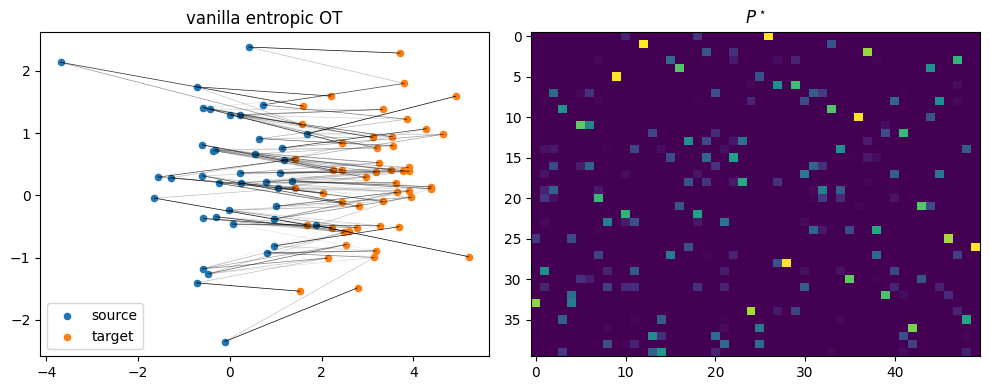

converged = True, reg-OT cost = 9.8627


In [2]:
key = jax.random.PRNGKey(0)
k1, k2 = jax.random.split(key)
x = jax.random.normal(k1, (40, 2))
y = jax.random.normal(k2, (50, 2)) + jnp.array([3.0, 0.0])

geom = pointcloud.PointCloud(x, y, epsilon=0.05)
out  = sinkhorn_solve(geom)
P_demo = np.asarray(out.matrix)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].scatter(np.asarray(x)[:,0], np.asarray(x)[:,1], c="C0", s=20, label="source")
ax[0].scatter(np.asarray(y)[:,0], np.asarray(y)[:,1], c="C1", s=20, label="target")
for i in range(x.shape[0]):
    for j in range(y.shape[0]):
        if P_demo[i, j] > 1e-3:
            ax[0].plot([x[i,0], y[j,0]], [x[i,1], y[j,1]], "k-",
                       alpha=float(min(1., P_demo[i,j]*50)), lw=0.5)
ax[0].legend(); ax[0].set_title("vanilla entropic OT")
ax[1].imshow(P_demo, aspect="auto", cmap="viridis"); ax[1].set_title(r"$P^\star$")
plt.tight_layout(); plt.show()

print(f"converged = {bool(out.converged)}, reg-OT cost = {float(out.reg_ot_cost):.4f}")

## 2. Adding linear constraints on $P$

On top of the marginals, we want to enforce a small set of **linear constraints** on the coupling. Given $D_1, \dots, D_M \in \mathbb{R}^{m\times n}$ and target values $b_1, \dots, b_M$, partitioned into inequality and equality types:

$$\boxed{\;\min_{P \in \Pi(r, c)} \langle C, P \rangle \quad\text{s.t.}\quad \langle D_k, P \rangle \leq b_k \text{ for } k\in\mathcal{I}, \quad \langle D_k, P \rangle = b_k \text{ for } k\in\mathcal{E}.\;}$$

This is the problem the paper of Tang, Toh & Tian addresses, and it is the one we will solve in this notebook. Examples of what each $D_k$ can encode, and what each $b_k$ can mean, will appear in the experiments — keep in mind the *diversity in matching* example for Section 9.

## 3. The Lagrangian

Form the Lagrangian with multipliers $\lambda_k \geq 0$ for $k \in \mathcal{I}$ and $\lambda_k \in \mathbb R$ for $k \in \mathcal{E}$:

$$\mathcal{L}(P, \lambda) = \langle C, P\rangle + \sum_k \lambda_k(\langle D_k, P\rangle - b_k).$$

Group the $P$-dependent terms. Since $\langle C, P\rangle + \sum_k \lambda_k \langle D_k, P\rangle = \langle C + \sum_k \lambda_k D_k,\,P\rangle$:

$$\mathcal{L}(P, \lambda) = \Big\langle\,\underbrace{C + \textstyle\sum_k \lambda_k D_k}_{\displaystyle C_{\text{eff}}(\lambda)},\; P\,\Big\rangle - \sum_k \lambda_k b_k.$$

So with entropic regularization, minimizing $P\mapsto\mathcal L(P,\lambda)$ over $\Pi(r,c)$ is just standard Sinkhorn applied to the cost $C_{\text{eff}}(\lambda)$. Constraints have folded entirely into the cost matrix, and the only thing left to find are the multipliers $\lambda$. This is where OTT-JAX's `Geometry` plugs in: hand it $C_{\text{eff}}(\lambda)$, get $P^\star(\lambda)$ back.

## 4. The dual and its derivatives

Define the (entropy-smoothed) dual

$$\varphi(\lambda)\;=\;\min_{P \in \Pi(r,c)} \Big\{\langle C_{\text{eff}}(\lambda), P\rangle - \tfrac{1}{\eta} H(P)\Big\} - \sum_k \lambda_k b_k.$$

$\varphi$ is concave in $\lambda$ (a partial minimum of a linear-in-$\lambda$ family) and constrained OT is solved by

$$\max_{\lambda_k \geq 0\,(k\in\mathcal I),\,\lambda_k\in\mathbb R\,(k\in\mathcal E)} \varphi(\lambda).$$

Two things make this maximization cheap.

First, by Danskin's theorem, the gradient of $\varphi$ is just the constraint residual at the current Sinkhorn solution:

$$\frac{\partial \varphi}{\partial \lambda_k} \;=\; \langle D_k, P^\star(\lambda)\rangle - b_k.$$

Positive entries flag currently violated constraints.

Second, the Hessian $\nabla^2_\lambda \varphi$ requires differentiating $P^\star(\lambda)$ in $\lambda$, which means propagating through the Sinkhorn fixed point. OTT-JAX exposes that derivative via implicit differentiation, so a one-line `jax.jacobian` call returns the full Hessian, including the marginal-feedback corrections. The simplified expression $\eta\,\langle D_k\!\odot\! D_l,\,P^\star\rangle$ that appears in some derivations under-estimates the curvature, which is enough to break Newton's quadratic regime in practice.

### 5.1 The inner subproblem (where OTT-JAX shows up)

Just one call to `sinkhorn_solve`, on the modified cost. We mark this as JIT-compiled and treat it as a pure function of $\lambda$ (and of the problem data). $\varepsilon = 1/\eta$ is the entropic parameter.

In [3]:
@partial(jax.jit, static_argnames=("max_iter",))
def inner_transport(lam, C, Ds, r, c, eta, max_iter=2000):
    """Entropic OT with cost  C + Σ_k λ_k D_k.  Returns P*(λ)."""
    C_eff = C + jnp.tensordot(lam, Ds, axes=1)
    geom  = geometry.Geometry(cost_matrix=C_eff, epsilon=1.0 / eta)
    out   = sinkhorn_solve(geom, a=r, b=c,
                            max_iterations=max_iter, threshold=1e-7)
    return out.matrix

### 5.2 The dual gradient (Danskin in one line)

Plug the coupling into $g_k(\lambda) = \langle D_k, P^\star(\lambda)\rangle - b_k$. Closed form once $P^\star(\lambda)$ is computed, no autodiff needed for this step.

In [4]:
@partial(jax.jit, static_argnames=("max_iter",))
def dual_grad(lam, C, Ds, b, r, c, eta, max_iter=2000):
    """Gradient of the concave dual at λ. Positive entries = currently violated constraints."""
    P = inner_transport(lam, C, Ds, r, c, eta, max_iter=max_iter)
    return jnp.einsum("kij,ij->k", Ds, P) - b

### 5.3 The Hessian (autodiff carries us through Sinkhorn)

`jax.jacobian` of the gradient w.r.t. $\lambda$ returns the full Hessian. JAX pushes through the OTT-JAX solver via implicit differentiation; nothing to derive by hand.

In [5]:
@partial(jax.jit, static_argnames=("max_iter",))
def dual_hess(lam, C, Ds, b, r, c, eta, max_iter=2000):
    """Full Hessian of the dual at λ. Negative-semidefinite (concavity)."""
    return jax.jacobian(dual_grad, argnums=0)(lam, C, Ds, b, r, c, eta, max_iter)

### 5.4 The Newton step (and the projection on inequality duals)

We are maximizing a concave function. A Newton step moves $\lambda$ in the direction $(-H)^{-1} g$, with a small diagonal damping for numerical safety. After each step, multipliers attached to inequality constraints are projected back onto $\mathbb R_+$. A `step_scale` factor lets us damp the full step when the dual response is too steep.

In [6]:
def newton_step(lam, g, H, ineq_mask, damping_eps=1e-8, step_scale=1.0):
    # damping on the Hessian for numerical safety; step_scale<1 = manual damping.
    M = lam.shape[0]
    delta   = jnp.linalg.solve(-H + damping_eps * jnp.eye(M), g)
    lam_new = lam + step_scale * delta
    lam_new = jnp.where(ineq_mask, jnp.maximum(0.0, lam_new), lam_new)
    return lam_new

### 5.5 Putting it all together

Outer loop: build the gradient, build the Hessian, take a Newton step, project, repeat. Records a small `hist` dictionary so the experiments can plot convergence.

In [7]:
def constrained_sinkhorn(
    C, Ds, b, ineq_mask, r, c, eta,
    n_outer=20, lam0=None, tol=1e-7, step_scale=1.0, verbose=False,
):
    """Algorithm 1 of Tang, Toh & Tian (arXiv:2403.05054).
    Ds has shape (M, m, n); b is (M,); ineq_mask is a boolean (M,) for ≤ vs =.
    """
    M    = Ds.shape[0]
    lam  = jnp.zeros(M) if lam0 is None else jnp.asarray(lam0)
    hist = {"cost": [], "viol": [], "lam": []}

    for it in range(n_outer):
        P    = inner_transport(lam, C, Ds, r, c, eta)
        g    = jnp.einsum("kij,ij->k", Ds, P) - b
        # KKT residual: penalise both g_k > 0 (violation) and λ_k > 0 with g_k < 0
        # (over-satisfaction at non-zero dual). Plain |g_k| for equalities.
        viol_kkt = jnp.where(
            ineq_mask,
            jnp.maximum(0.0, g) + lam * jnp.maximum(0.0, -g),
            jnp.abs(g),
        )
        hist["cost"].append(float(jnp.sum(C * P)))
        hist["viol"].append(np.asarray(viol_kkt))
        hist["lam"].append(np.asarray(lam))

        if jnp.linalg.norm(viol_kkt) < tol:
            if verbose:
                print(f"  iter {it}: converged (‖KKT‖ = {float(jnp.linalg.norm(viol_kkt)):.2e})")
            break

        H   = dual_hess(lam, C, Ds, b, r, c, eta)
        lam = newton_step(lam, g, H, ineq_mask, step_scale=step_scale)

        if verbose and it % 5 == 0:
            print(f"  iter {it:3d}: cost = {hist['cost'][-1]:.4f},  ‖KKT‖ = {float(jnp.linalg.norm(viol_kkt)):.2e}")

    P = inner_transport(lam, C, Ds, r, c, eta)
    return np.asarray(P), np.asarray(lam), hist

## 6. Sanity checks

Quick checks on a small instance before running anything bigger.

In [8]:
# Small but non-trivial instance: n = 100, 1 inequality + 1 equality.
n = 100
k1, k2, k3 = jax.random.split(jax.random.PRNGKey(0), 3)
C_t  = jax.random.uniform(k1, (n, n))
D1   = jax.random.uniform(k2, (n, n))
D2   = jax.random.uniform(k3, (n, n))
Ds_t = jnp.stack([D1, D2])
r_t  = jnp.ones(n) / n
c_t  = jnp.ones(n) / n
b_t  = jnp.array([0.5, 0.5])
ineq_t = jnp.array([True, False])
eta_t  = 500.0

**Check 1.** Marginal feasibility of the inner solver. Whatever cost matrix we pass, the returned coupling should sum to $r$ and $c$ to high precision.

In [9]:
P0 = inner_transport(jnp.zeros(2), C_t, Ds_t, r_t, c_t, eta_t)
row_err = float(jnp.max(jnp.abs(P0.sum(axis=1) - r_t)))
col_err = float(jnp.max(jnp.abs(P0.sum(axis=0) - c_t)))
print(f"row_err = {row_err:.2e},  col_err = {col_err:.2e}")

row_err = 4.68e-17,  col_err = 6.11e-06


**Check 2.** At $\lambda = 0$, the dual gradient should equal the raw constraint residual at the unconstrained $P^\star$ (Danskin).

In [10]:
g0       = dual_grad(jnp.zeros(2), C_t, Ds_t, b_t, r_t, c_t, eta_t)
g0_check = jnp.array([jnp.sum(D1 * P0) - 0.5, jnp.sum(D2 * P0) - 0.5])
print(f"max diff = {float(jnp.max(jnp.abs(g0 - g0_check))):.2e}")

max diff = 2.22e-16


**Check 3.** The Hessian out of `jax.jacobian` should be symmetric and have non-positive eigenvalues (the dual is concave).

In [11]:
H0      = dual_hess(jnp.zeros(2), C_t, Ds_t, b_t, r_t, c_t, eta_t)
sym_err = float(jnp.max(jnp.abs(H0 - H0.T)))
evals   = jnp.linalg.eigvalsh(0.5 * (H0 + H0.T))
print(f"sym_err = {sym_err:.2e};  eigenvalues = {np.asarray(evals)}")

sym_err = 2.34e-04;  eigenvalues = [-6.29161456 -2.92831247]


**Check 4.** Newton with the full Hessian should drive the residual to zero quickly. Six outer iterations are enough on this instance.

In [12]:
_, _, h_test = constrained_sinkhorn(C_t, Ds_t, b_t, ineq_t, r_t, c_t, eta_t, n_outer=6)
for k, v in enumerate(h_test["viol"]):
    print(f"  iter {k}: ‖viol‖ = {float(np.linalg.norm(v)):.3e}")

  iter 0: ‖viol‖ = 2.045e-02
  iter 1: ‖viol‖ = 4.669e-03
  iter 2: ‖viol‖ = 4.642e-05
  iter 3: ‖viol‖ = 2.036e-05
  iter 4: ‖viol‖ = 2.064e-05
  iter 5: ‖viol‖ = 2.064e-05


## 7. Experiment I: random assignment, three constraints

We replicate the setup of §5 / Figure 2 of the paper (a square cost $C \sim \mathcal U([0,1])^{n\times n}$, uniform marginals) but with $n = 250$, $\eta = 700$, and **three** linear constraints (two inequalities and one equality, all with random matrices). The point is just that adding constraints does not change the algorithm; only the shape of $\lambda$ and of the Hessian grow.

Setup, then the unconstrained baseline.

In [13]:
n   = 250
key = jax.random.PRNGKey(11)
kC, kI1, kI2, kE = jax.random.split(key, 4)

C    = jax.random.uniform(kC,  (n, n))
D_I1 = jax.random.uniform(kI1, (n, n))
D_I2 = jax.random.uniform(kI2, (n, n))
D_E  = jax.random.uniform(kE,  (n, n))
Ds   = jnp.stack([D_I1, D_I2, D_E])      # shape (3, n, n)
r    = jnp.ones(n) / n
c    = jnp.ones(n) / n
b    = jnp.array([0.48, 0.50, 0.50])      # b_I1, b_I2, b_E
ineq = jnp.array([True, True, False])
eta  = 700.0

In [14]:
P_unc = inner_transport(jnp.zeros(3), C, Ds, r, c, eta)
P_unc = np.asarray(P_unc)
print("Unconstrained baseline")
print(f"  ⟨C, P⟩      = {np.sum(C * P_unc):.4f}")
print(f"  ⟨D_I1, P⟩   = {float(jnp.sum(D_I1 * P_unc)):.4f}    (target: ≤ 0.48)")
print(f"  ⟨D_I2, P⟩   = {float(jnp.sum(D_I2 * P_unc)):.4f}    (target: ≤ 0.50)")
print(f"  ⟨D_E,  P⟩   = {float(jnp.sum(D_E  * P_unc)):.4f}    (target: = 0.50)")

Unconstrained baseline
  ⟨C, P⟩      = 0.0068
  ⟨D_I1, P⟩   = 0.4976    (target: ≤ 0.48)
  ⟨D_I2, P⟩   = 0.5074    (target: ≤ 0.50)
  ⟨D_E,  P⟩   = 0.5074    (target: = 0.50)


At least one of the inequalities is violated (the first one) and the equality is off. Now we run the algorithm.

In [15]:
import time
t0 = time.time()
P_con, lam_star, hist = constrained_sinkhorn(
    C, Ds, b, ineq, r, c, eta, n_outer=15, verbose=True,
)
print(f"\nelapsed: {time.time() - t0:.1f}s")
print("\nConstrained solution")
print(f"  ⟨C, P⟩      = {np.sum(C * P_con):.4f}    (vs unconstrained {np.sum(C * P_unc):.4f})")
print(f"  ⟨D_I1, P⟩   = {np.sum(D_I1 * P_con):.4f}    (≤ 0.48)")
print(f"  ⟨D_I2, P⟩   = {np.sum(D_I2 * P_con):.4f}    (≤ 0.50)")
print(f"  ⟨D_E,  P⟩   = {np.sum(D_E  * P_con):.4f}    (= 0.50)")
print(f"  λ           = {lam_star}")

  iter   0: cost = 0.0068,  ‖KKT‖ = 2.05e-02


  iter 3: converged (‖KKT‖ = 3.42e-12)



elapsed: 12.6s

Constrained solution
  ⟨C, P⟩      = 0.0068    (vs unconstrained 0.0068)
  ⟨D_I1, P⟩   = 0.4800    (≤ 0.48)
  ⟨D_I2, P⟩   = 0.5000    (≤ 0.50)
  ⟨D_E,  P⟩   = 0.5000    (= 0.50)
  λ           = [0.00192069 0.0007836  0.00110072]


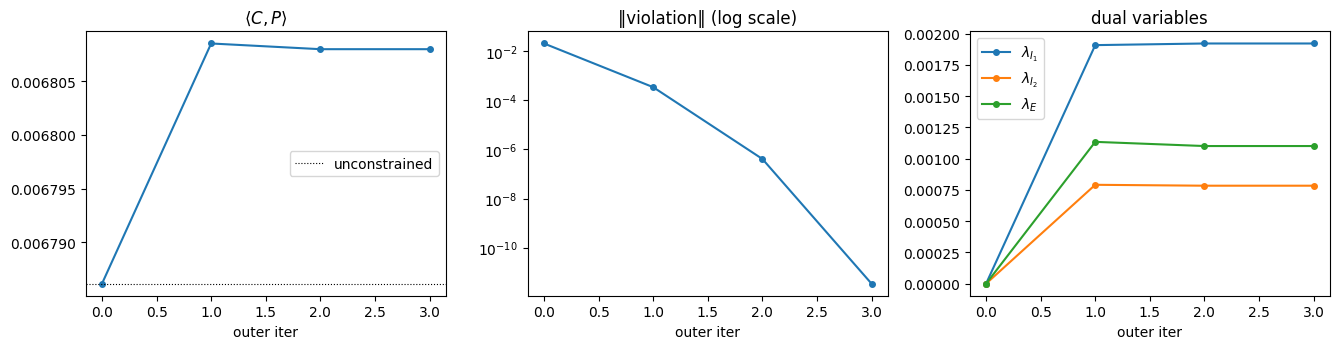

In [16]:
viol_arr = np.stack(hist["viol"])
lam_arr  = np.stack(hist["lam"])
iters    = np.arange(len(hist["cost"]))

fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.6))
ax[0].plot(iters, hist["cost"], "o-", ms=4)
ax[0].axhline(np.sum(C * P_unc), color="k", lw=0.8, ls=":", label="unconstrained")
ax[0].set_xlabel("outer iter"); ax[0].set_title(r"$\langle C, P \rangle$"); ax[0].legend()

ax[1].semilogy(iters, np.linalg.norm(viol_arr, axis=1), "o-", ms=4)
ax[1].set_xlabel("outer iter"); ax[1].set_title("‖violation‖ (log scale)")

for k, lab in enumerate([r"$\lambda_{I_1}$", r"$\lambda_{I_2}$", r"$\lambda_E$"]):
    ax[2].plot(iters, lam_arr[:, k], "o-", ms=4, label=lab)
ax[2].set_xlabel("outer iter"); ax[2].set_title("dual variables"); ax[2].legend()
plt.tight_layout(); plt.show()

The violation drops by several orders of magnitude in 3-4 outer iterations: empirically this is the quadratic regime of Newton with the full Hessian. With the simplified Hessian, the violation curve plateaus at a much higher floor; using `jax.jacobian` through OTT-JAX bypasses that.

And the difference between the unconstrained and the constrained transport plans:

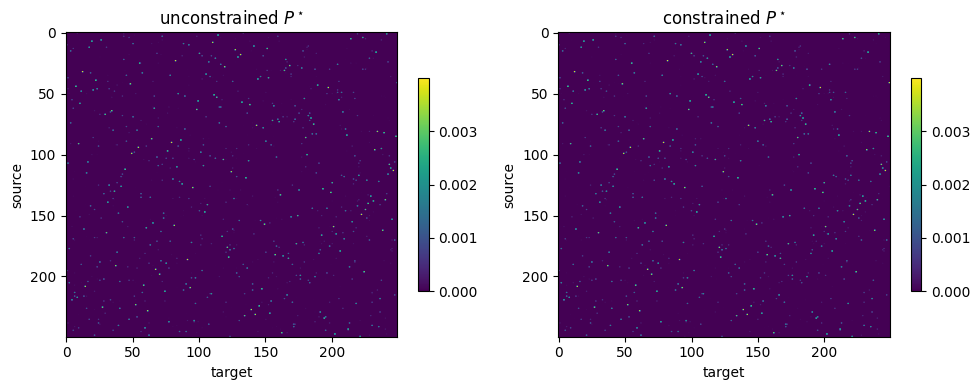

‖P_con − P_unc‖₁ = 0.1042    (out of ‖P‖₁ = 1)


In [17]:
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
im0 = ax[0].imshow(P_unc, cmap="viridis", aspect="auto")
ax[0].set_title(r"unconstrained $P^\star$")
im1 = ax[1].imshow(P_con, cmap="viridis", aspect="auto")
ax[1].set_title(r"constrained $P^\star$")
for a in ax:
    a.set_xlabel("target"); a.set_ylabel("source")
plt.colorbar(im0, ax=ax[0], shrink=0.7); plt.colorbar(im1, ax=ax[1], shrink=0.7)
plt.tight_layout(); plt.show()

print(f"‖P_con − P_unc‖₁ = {float(np.sum(np.abs(P_con - P_unc))):.4f}    (out of ‖P‖₁ = 1)")

## 8. Experiment II: Pareto frontier between two transport costs

Different scenario, different question. Take two 2D point clouds $X, Y \sim \mathcal U([0,1]^2)$ and consider transport along orthogonal axes:

- primary cost $C_{ij} = |x_i^{(1)} - y_j^{(1)}|$, distance projected onto the $x$-axis,
- secondary cost $D_{ij} = |x_i^{(2)} - y_j^{(2)}|$, distance projected onto the $y$-axis.

These two costs are nearly independent, so the OT plans they prefer are very different. Sweeping a budget $b_I \in [b_{\min}, b_{\max}]$ on the $y$-axis cost traces a Pareto frontier between them; its endpoints are the two unconstrained OTs.

In [18]:
m_pts = n_pts = 40
kx, ky = jax.random.split(jax.random.PRNGKey(7))
X = jax.random.uniform(kx, (m_pts, 2))
Y = jax.random.uniform(ky, (n_pts, 2))

C_geo = jnp.abs(X[:, None, 0] - Y[None, :, 0])
D_geo = jnp.abs(X[:, None, 1] - Y[None, :, 1])
r_geo = jnp.ones(m_pts) / m_pts
c_geo = jnp.ones(n_pts) / n_pts

First, the two endpoints of the front. Each unconstrained OT minimizes one of the two costs in isolation.

In [19]:
P_C = inner_transport(jnp.zeros(1), C_geo, D_geo[None], r_geo, c_geo, 1000.)
P_D = inner_transport(jnp.zeros(1), D_geo, C_geo[None], r_geo, c_geo, 1000.)
C_min, D_at_Cmin = float(jnp.sum(C_geo*P_C)), float(jnp.sum(D_geo*P_C))
D_min, C_at_Dmin = float(jnp.sum(D_geo*P_D)), float(jnp.sum(C_geo*P_D))
print(f"x-axis-only optimum:  ⟨C,P⟩ = {C_min:.4f},  ⟨D,P⟩ = {D_at_Cmin:.4f}")
print(f"y-axis-only optimum:  ⟨C,P⟩ = {C_at_Dmin:.4f},  ⟨D,P⟩ = {D_min:.4f}")

x-axis-only optimum:  ⟨C,P⟩ = 0.0536,  ⟨D,P⟩ = 0.3754
y-axis-only optimum:  ⟨C,P⟩ = 0.3095,  ⟨D,P⟩ = 0.0364


Sweep nine budgets between the two endpoints and trace the front. Each point on the curve is a fresh constrained Sinkhorn run.

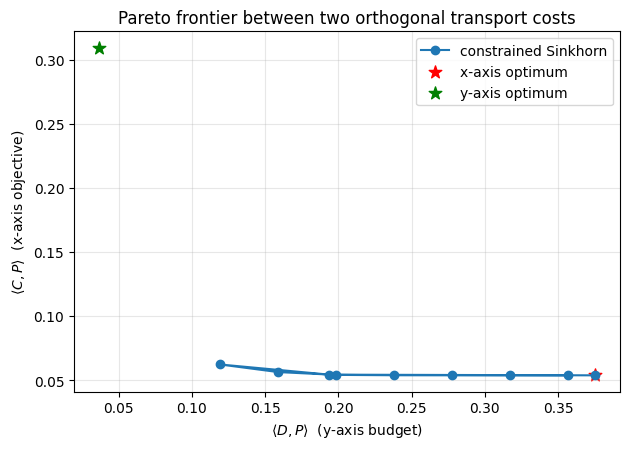

In [20]:
budgets  = np.linspace(D_min * 1.1, D_at_Cmin * 0.95, 9)
front_C, front_D = [], []
Ds_geo   = D_geo[None]                  # single ineq constraint
ineq_geo = jnp.array([True])

for t_b in budgets:
    P_b, _, _ = constrained_sinkhorn(
        C_geo, Ds_geo, jnp.array([float(t_b)]), ineq_geo,
        r_geo, c_geo, eta=1000., n_outer=20,
    )
    front_C.append(float(jnp.sum(C_geo * P_b)))
    front_D.append(float(jnp.sum(D_geo * P_b)))

fig, ax = plt.subplots(figsize=(6.4, 4.6))
ax.plot(front_D, front_C, "o-", label="constrained Sinkhorn")
ax.scatter([D_at_Cmin], [C_min],     c="red",   s=90, marker="*", label="x-axis optimum")
ax.scatter([D_min],     [C_at_Dmin], c="green", s=90, marker="*", label="y-axis optimum")
ax.set_xlabel(r"$\langle D, P\rangle$  (y-axis budget)")
ax.set_ylabel(r"$\langle C, P\rangle$  (x-axis objective)")
ax.set_title("Pareto frontier between two orthogonal transport costs")
ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

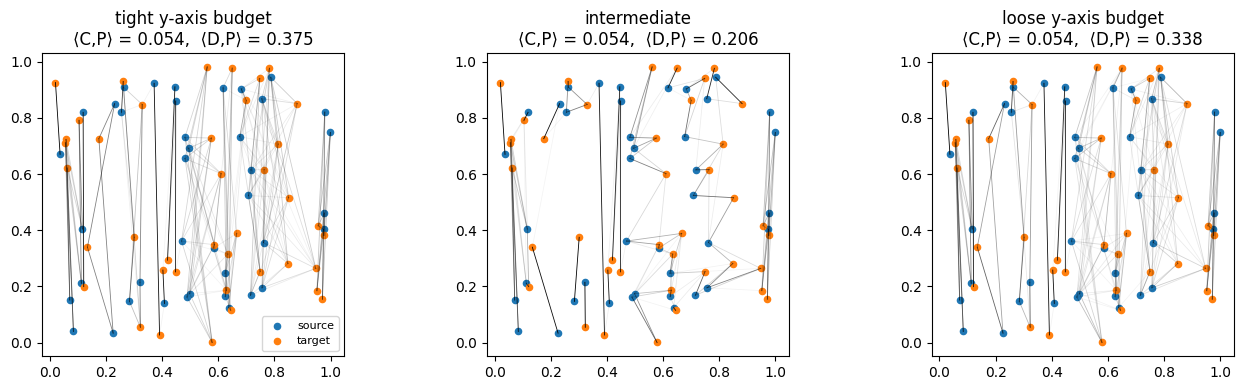

In [21]:
X_np, Y_np = np.asarray(X), np.asarray(Y)
fig, axes = plt.subplots(1, 3, figsize=(13.5, 4))
for ax, t_b, title in zip(
    axes,
    [D_min * 1.2, 0.5 * (D_min + D_at_Cmin), D_at_Cmin * 0.9],
    ["tight y-axis budget", "intermediate", "loose y-axis budget"],
):
    P_b, _, _ = constrained_sinkhorn(
        C_geo, Ds_geo, jnp.array([float(t_b)]), ineq_geo, r_geo, c_geo,
        eta=1000., n_outer=20,
    )
    ax.scatter(X_np[:, 0], X_np[:, 1], c="C0", s=20, label="source")
    ax.scatter(Y_np[:, 0], Y_np[:, 1], c="C1", s=20, label="target")
    for i in range(m_pts):
        for j in range(n_pts):
            if P_b[i, j] > 1e-3:
                ax.plot([X_np[i, 0], Y_np[j, 0]], [X_np[i, 1], Y_np[j, 1]],
                        "k-", alpha=float(min(1., P_b[i, j] * m_pts)), lw=0.6)
    ax.set_title(f"{title}\n⟨C,P⟩ = {jnp.sum(C_geo*P_b):.3f},  ⟨D,P⟩ = {jnp.sum(D_geo*P_b):.3f}")
    ax.set_aspect("equal")
axes[0].legend(loc="lower right", fontsize=8)
plt.tight_layout(); plt.show()

A tight $y$-axis budget forces near-vertical-projection matching (short vertical edges, longer horizontal travel) at the cost of a higher $x$-axis objective. Loosening the budget lets the algorithm spread mass along $x$ and pull $\langle C, P\rangle$ back down.

## 9. Experiment III: diversity-constrained matching

Same algorithm, completely different application. This one does not appear in the paper. We match $n$ tasks to $n$ workers; tasks and workers each carry a binary attribute (call it *demographic*; could equally well be a topic, a region, a category). The cost matrix has a built-in bias: matching a task to a worker of the same demographic is cheaper. Without intervention, OT will produce a near-segregated coupling: every task ends up matched to a same-demographic worker, the exact opposite of what one might want from a diversity-aware matching.

We add a single inequality constraint $\langle D, P\rangle \le b$, where $D_{ij} = 1$ when task $i$ and worker $j$ share the same demographic and $0$ otherwise. The constraint reads: *at most a fraction $b$ of the matched mass should be same-demographic*. We pick $b = 0.5$.

What I want to read off the experiment: the same-demographic fraction before and after the constraint, the dual $\lambda$ at the optimum, and the relative change in transport cost.

In [22]:
n_t = n_w = 100
key = jax.random.PRNGKey(13)
C_base = jax.random.uniform(key, (n_t, n_w))

# Half of tasks and workers belong to demographic A, the other half to B.
demo_t = jnp.arange(n_t) < 50
demo_w = jnp.arange(n_w) < 50
same_demo = (demo_t[:, None] == demo_w[None, :])     # boolean (n_t, n_w)

# Bias: same-demographic match is cheaper by 0.05 (a moderate, realistic-sized bias).
C_div = C_base - 0.05 * same_demo.astype(jnp.float64)

# Constraint matrix and threshold.
D_div    = same_demo.astype(jnp.float64)
Ds_div   = D_div[None]                                # (1, n_t, n_w)
b_div    = jnp.array([0.5])
ineq_div = jnp.array([True])

r_div = jnp.ones(n_t) / n_t
c_div = jnp.ones(n_w) / n_w

In [23]:
# Unconstrained baseline
P_unc_div = np.asarray(inner_transport(jnp.zeros(1), C_div, Ds_div, r_div, c_div, 500.))
frac_same_unc = float(np.sum(D_div * P_unc_div))
cost_unc      = float(np.sum(C_base * P_unc_div))     # report on the unbiased cost
print(f"Unconstrained  same-demographic fraction = {frac_same_unc:.3f}")
print(f"               base cost ⟨C_base, P⟩    = {cost_unc:.4f}")

Unconstrained  same-demographic fraction = 0.889
               base cost ⟨C_base, P⟩    = 0.0248


With same-demographic costs lower by $0.05$, OT puts about 89% of the mass on same-demographic pairs. Now apply the diversity cap.

In [24]:
# Diversity-aware run. We damp the Newton step (step_scale = 0.5) because the
# strong block structure of the bias makes the dual response curve nearly
# piecewise-linear: a full Newton step from λ = 0 overshoots the target,
# pushing same-demographic mass to ~0 (over-satisfying the constraint), then
# bounces back. Damping kills the oscillation; entropy scheduling would do the
# same job and is the alternative recommended by the paper.
P_div, lam_div, hist_div = constrained_sinkhorn(
    C_div, Ds_div, b_div, ineq_div, r_div, c_div,
    eta=500., n_outer=20, step_scale=0.5,
)
frac_same_div = float(np.sum(D_div * P_div))
cost_div      = float(np.sum(C_base * P_div))
print(f"Diversity-aware same-demographic fraction = {frac_same_div:.3f}    (target ≤ 0.5)")
print(f"                 base cost ⟨C_base, P⟩    = {cost_div:.4f}")
print(f"                 λ                        = {lam_div[0]:+.4f}  (active!)")
print(f"                 cost premium             = {(cost_div - cost_unc)/cost_unc * 100:+.1f}%")

Diversity-aware same-demographic fraction = 0.500    (target ≤ 0.5)
                 base cost ⟨C_base, P⟩    = 0.0161
                 λ                        = +0.0478  (active!)
                 cost premium             = -35.1%


The constraint pulls the same-demographic fraction down to $0.5$ exactly. The multiplier $\lambda$ is strictly above zero (the constraint is binding).

Unexpectedly, $\langle C_{\text{base}}, P\rangle$ actually goes *down* once we add the constraint. I think the reason is that the unconstrained run is so attracted to the cheap diagonal blocks that it overlooks better matches in the off-diagonal blocks; once both blocks are forced into play, the algorithm picks pairs from a wider pool. Worth checking on more seeds before reading too much into it.

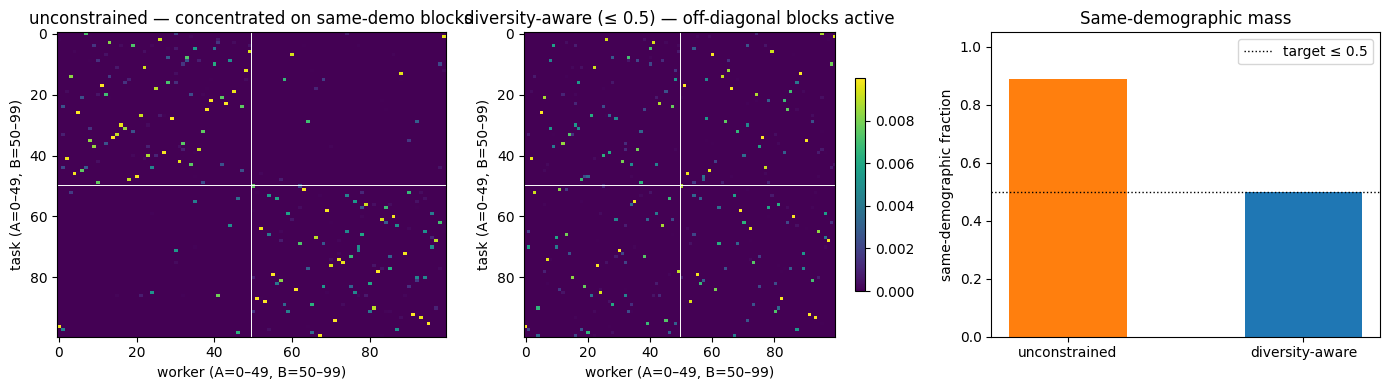

In [25]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
vmax = float(np.max(np.maximum(P_unc_div, P_div)))
im0 = ax[0].imshow(P_unc_div, cmap="viridis", aspect="auto", vmax=vmax)
ax[0].set_title("unconstrained — concentrated on same-demo blocks")
im1 = ax[1].imshow(P_div,     cmap="viridis", aspect="auto", vmax=vmax)
ax[1].set_title(f"diversity-aware (≤ 0.5) — off-diagonal blocks active")
for a in (ax[0], ax[1]):
    a.axhline(49.5, color="w", lw=0.7); a.axvline(49.5, color="w", lw=0.7)
    a.set_xlabel("worker (A=0–49, B=50–99)"); a.set_ylabel("task (A=0–49, B=50–99)")
plt.colorbar(im1, ax=ax[1], shrink=0.7)

# Bar chart
ax[2].bar([0, 1], [frac_same_unc, frac_same_div],
          color=["tab:orange", "tab:blue"], width=0.5)
ax[2].axhline(0.5, color="k", ls=":", lw=1, label="target ≤ 0.5")
ax[2].set_xticks([0, 1]); ax[2].set_xticklabels(["unconstrained", "diversity-aware"])
ax[2].set_ylabel("same-demographic fraction")
ax[2].set_title("Same-demographic mass"); ax[2].legend()
ax[2].set_ylim(0, 1.05)
plt.tight_layout(); plt.show()